In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyscf import gto, scf, mcscf, ao2mo
from qchem.utils import  (
    MoleculeData,
    get_hf_gse_from_mol,
    one_electron_integral_transform,
    two_electron_integral_transform,
    DMDMWorkflow,
    CalculationMode,
    scale_molecule_v2,
    write_dalton_molecule_file,
    parse_dalton_output,
    gaussian
    )

from dmdm.interface import DMDM
import qrunch as qc


qc.register_license_file("/home/flemming/Nextcloud/Cherimoya/training/master_cs/ms_project/code/qchem/license_fm.txt")

/home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/qrunch/core/public_api.py:254: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  module = cast(_ImportCallable, _original_import)(name, globals, locals, fromlist, level)
/home/flemming/Nextcloud/Cherimoya/training/master_cs/ms_project/code/qchem/src/qchem/utils.py:13: UserWarning: The module 'qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator' is not part of the public API of 'qrunch'. Its interface may change without notice.
The module was imported from qchem.utils.
  from qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator import ReducedDensityMatrixCalculator
/home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/qrunch/common/register_license.py:125: UserWarning: A license file already exists at user config path /home/flemming/.local/share/qrunch/license.txt. Will NOT

In [2]:
scaling_factors = np.linspace(1.0, 4.0, 31)
num_states = 4
mol = MoleculeData.molecules["LiH"]["coords"]
mol


[('Li', 0.0, 0.0, 0.0), ('H', 0.0, 0.0, 1.595)]

# VQE

In [14]:
vqe_dfs = []
for factor in scaling_factors:
    workflow = DMDMWorkflow(
        basis="cc-pvdz",
        # molecule=MoleculeData.molecules["LiH"]["coords"], # String key for qchem MoleculeData
        molecule=mol,
        num_active_orbitals=2,
        num_active_electrons=2,
        num_states=4,
        mode=CalculationMode.BOTH,
        vqe_max_iterations=500
    )

    # VQE only
    result = workflow.run_quantum_vqe()

    vqe_dfs.append(
        pd.DataFrame({
            "State": [*range(1, len(result["exc_energies_ev"])+1)],
            "Energy_eV": result["exc_energies_ev"],
            "scale": [factor] * len(result["exc_energies_ev"]),
            "Oscillator_F_Total": result["oscillator_strengths"]
        })
    )

vqe_df = pd.concat(vqe_dfs, axis=0).reset_index()

  Inactive: 1, Active: 2, Virtual: 16
idx, max(abs(grad orb)): 96 0.00029298566351314227
idx, max(abs(grad active)): 3 0.004961754158384422
Smallest Hessian eigenvalue: (-0.5007156340769966+0j)
Smallest diagonal element in the metric: 0.0001415818397260127
  Inactive: 1, Active: 2, Virtual: 16
idx, max(abs(grad orb)): 46 0.0002929856635131532
idx, max(abs(grad active)): 3 0.004961754158384473
Smallest Hessian eigenvalue: (-0.5007156340769986+0j)
Smallest diagonal element in the metric: 0.00014158183972612373
  Inactive: 1, Active: 2, Virtual: 16
idx, max(abs(grad orb)): 46 0.00029298566351313815
idx, max(abs(grad active)): 3 0.004961754158384379
Smallest Hessian eigenvalue: (-0.5007156340769957+0j)
Smallest diagonal element in the metric: 0.0001415818397260127
  Inactive: 1, Active: 2, Virtual: 16
idx, max(abs(grad orb)): 46 0.000292985663513171
idx, max(abs(grad active)): 3 0.004961754158384376
Smallest Hessian eigenvalue: (-0.500715634077001+0j)
Smallest diagonal element in the metri

In [30]:
result

{'exc_energies_ev': array([0.        , 4.11277504]),
 'oscillator_strengths': array([0.       , 0.0586243]),
 'dmdm_obj': <dmdm.interface.DMDM at 0x7f1cf6d7d710>}

,State,Energy_eV,scale
0,1,0.000000,1.0
1,2,4.112775,1.0
2,3,18.546977,1.0


# CASSCF

In [4]:
for factor in scaling_factors:
    write_dalton_molecule_file(
        scale_molecule_v2(mol, factor),
        f"../dalton_scripts/lih_{round(factor, 1)}.mol",
        molecule_name=f"LiH scaled: {round(factor, 1)}"
    )

In [5]:
# print commands
for factor in scaling_factors:
    print(
        f"dalton -dal lih.dal -mol lih_{round(factor, 1)}.mol -o lih_{round(factor, 1)}.out"
    )

dalton -dal lih.dal -mol lih_1.0.mol -o lih_1.0.out
dalton -dal lih.dal -mol lih_1.1.mol -o lih_1.1.out
dalton -dal lih.dal -mol lih_1.2.mol -o lih_1.2.out
dalton -dal lih.dal -mol lih_1.3.mol -o lih_1.3.out
dalton -dal lih.dal -mol lih_1.4.mol -o lih_1.4.out
dalton -dal lih.dal -mol lih_1.5.mol -o lih_1.5.out
dalton -dal lih.dal -mol lih_1.6.mol -o lih_1.6.out
dalton -dal lih.dal -mol lih_1.7.mol -o lih_1.7.out
dalton -dal lih.dal -mol lih_1.8.mol -o lih_1.8.out
dalton -dal lih.dal -mol lih_1.9.mol -o lih_1.9.out
dalton -dal lih.dal -mol lih_2.0.mol -o lih_2.0.out
dalton -dal lih.dal -mol lih_2.1.mol -o lih_2.1.out
dalton -dal lih.dal -mol lih_2.2.mol -o lih_2.2.out
dalton -dal lih.dal -mol lih_2.3.mol -o lih_2.3.out
dalton -dal lih.dal -mol lih_2.4.mol -o lih_2.4.out
dalton -dal lih.dal -mol lih_2.5.mol -o lih_2.5.out
dalton -dal lih.dal -mol lih_2.6.mol -o lih_2.6.out
dalton -dal lih.dal -mol lih_2.7.mol -o lih_2.7.out
dalton -dal lih.dal -mol lih_2.8.mol -o lih_2.8.out
dalton -dal 

In [17]:
# Plot the energies and oscillator strengths
folder = "../dalton_scripts/"

dfs = []

for factor in scaling_factors:
    file_name = f"../dalton_scripts/lih_{round(factor, 1)}.out"
    df = parse_dalton_output(file_name)
    df["scale"] = len(df) * [factor]
    dfs.append(df)

df = pd.concat(dfs, axis=0)

In [18]:
df

,State,Energy_au,Energy_eV,Oscillator_F_X,Oscillator_F_Y,Oscillator_F_Z,Oscillator_F_Total,scale
0,1,0.117266,3.190969,2.574667e-33,2.309470e-30,2.409850e-02,0.024098,1.0
1,2,0.154504,4.204258,1.122046e-01,1.021544e-01,7.576505e-30,0.214359,1.0
2,3,0.154504,4.204258,1.013852e-01,1.129737e-01,1.432453e-29,0.214359,1.0
3,4,0.226526,6.164085,2.354700e-31,8.744335e-30,3.339300e-02,0.033393,1.0
0,1,0.124332,3.383243,4.951312e-30,5.825864e-32,2.897390e-02,0.028974,1.1
...,...,...,...,...,...,...,...,...
3,4,0.161683,4.399612,3.967966e-31,2.051699e-30,4.893471e-02,0.048935,3.9
0,1,0.051117,1.390952,7.638809e-31,3.267391e-30,2.578793e-01,0.257879,4.0
1,2,0.078849,2.145578,1.884232e-01,6.725718e-02,1.476899e-29,0.255680,4.0
2,3,0.078849,2.145578,2.355536e-01,2.012672e-02,8.622881e-30,0.255680,4.0


/tmp/ipykernel_1071/4139601713.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


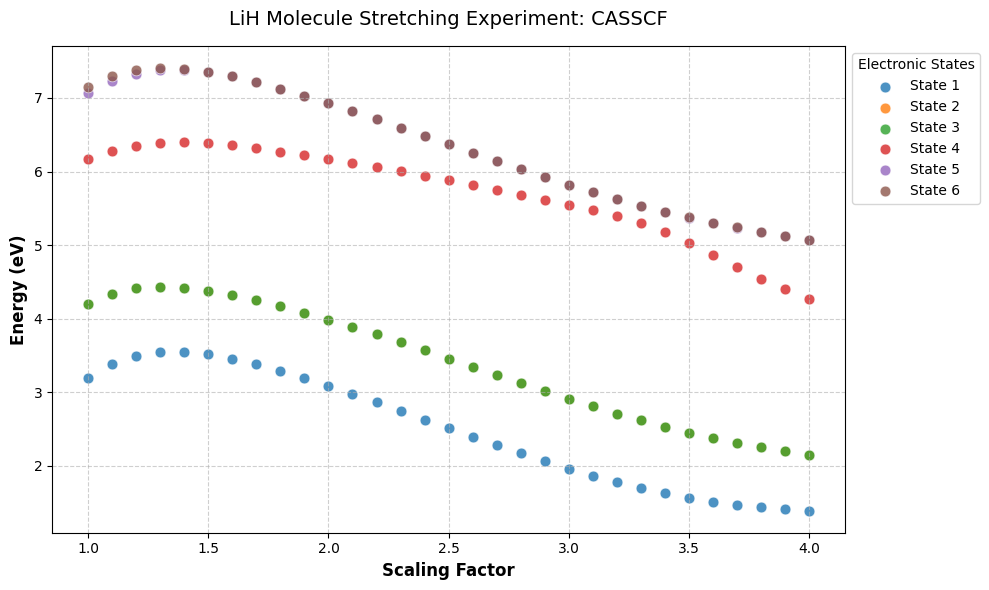

In [8]:
palette = plt.cm.tab10.colors 

fig, ax = plt.subplots(figsize=(10, 6))
for state in range(1, 7):
    current_df = df[df["State"] == state]
    
    # Safety check: skip if no data for this state
    if current_df.empty:
        continue
        
    # Plot with distinct markers and colors
    # Using 'o' for circles, and mapping color to state index
    color = palette[(state - 1) % len(palette)]
    
    ax.scatter(
        current_df["scale"], 
        current_df["Energy_eV"], 
        label=f"State {state}", 
        alpha=0.8, 
        s=60,           # Marker size
        edgecolors='w', # White edges for better visibility
        linewidth=0.5,
        c=color         # Explicitly set color
    )

# Enhance the plot aesthetics
ax.set_xlabel("Scaling Factor", fontsize=12, fontweight='bold')
ax.set_ylabel("Energy (eV)", fontsize=12, fontweight='bold')
ax.set_title("LiH Molecule Stretching Experiment: CASSCF", fontsize=14, pad=15)

# Add a grid for easier reading of values
ax.grid(True, linestyle='--', alpha=0.6)

# Place legend outside the plot area to avoid covering data
ax.legend(title="Electronic States", loc='upper left', bbox_to_anchor=(1, 1))

# Adjust layout to prevent legend from being cut off
plt.tight_layout()

plt.show()

/tmp/ipykernel_1071/1851384064.py:34: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


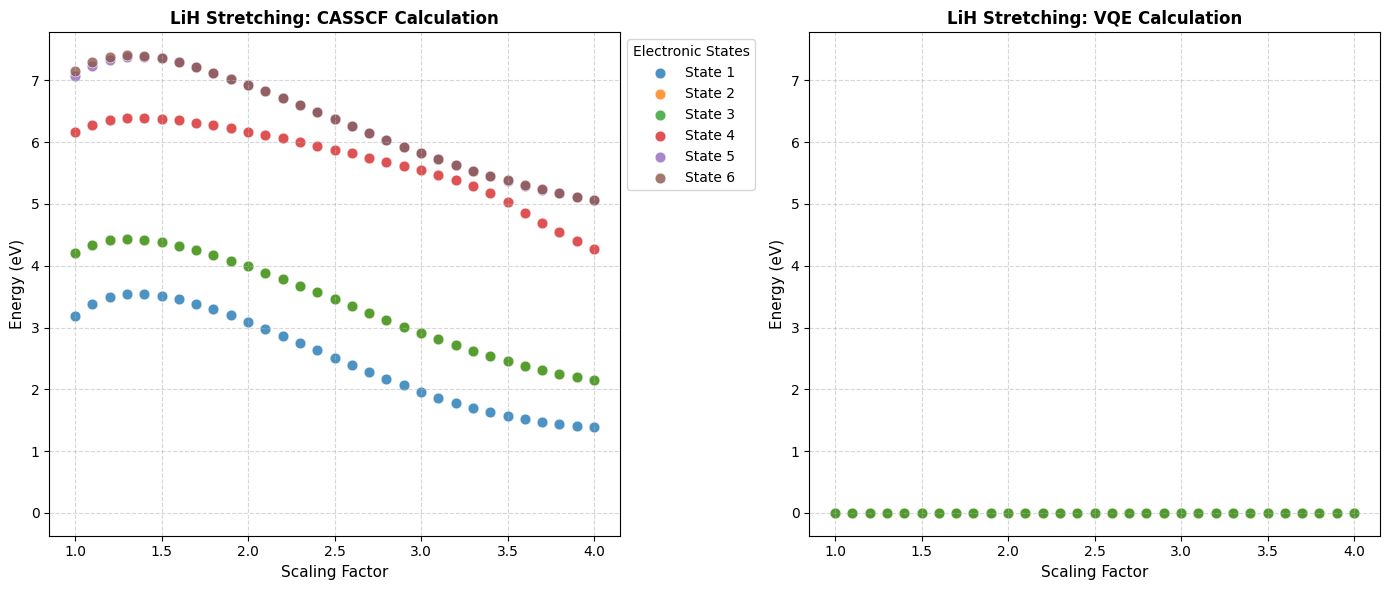

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have the dataframes ready (assuming 'df' and 'vqe_df' exist in your environment)
# If 'vqe_df' has different column names, adjust them below.
# Assuming columns are: "scale", "Energy_eV", "State"

# 1. Calculate Global Axis Limits to ensure consistency across both plots
all_scales = np.concatenate([df["scale"].values, vqe_df["scale"].values])
all_energies = np.concatenate([df["Energy_eV"].values, vqe_df["Energy_eV"].values])

# Add a small margin (5%) to the limits so points don't sit exactly on the border
x_margin = (all_scales.max() - all_scales.min()) * 0.05
y_margin = (all_energies.max() - all_energies.min()) * 0.05

xlim_min, xlim_max = all_scales.min() - x_margin, all_scales.max() + x_margin
ylim_min, ylim_max = all_energies.min() - y_margin, all_energies.max() + y_margin

# 2. Create the figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Define a shared color palette
palette = plt.cm.tab10.colors

def plot_molecule_data(ax, data_source, title, df_input):
    """Helper function to plot data on a specific axis."""
    for state in range(1, 7):
        current_df = df_input[df_input["State"] == state]
        if current_df.empty:
            continue
            
        color = palette[(state - 1) % len(palette)]
        
        ax.scatter(
            current_df["scale"], 
            current_df["Energy_eV"], 
            label=f"State {state}", 
            alpha=0.8, 
            s=60, 
            edgecolors='w', 
            linewidth=0.5,
            c=color
        )
    
    # Apply shared limits
    ax.set_xlim(xlim_min, xlim_max)
    ax.set_ylim(ylim_min, ylim_max)
    
    # Styling
    ax.set_xlabel("Scaling Factor", fontsize=11)
    ax.set_ylabel("Energy (eV)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Only show legend on the first plot to avoid clutter, or show on both if preferred
    # Here we put it on the left plot
    if ax == ax1:
        ax.legend(title="Electronic States", loc='upper left', bbox_to_anchor=(1, 1))

# 3. Plot the first dataset (Standard DF)
plot_molecule_data(ax1, df, "LiH Stretching: CASSCF Calculation", df)

# 4. Plot the second dataset (VQE DF)
plot_molecule_data(ax2, vqe_df, "LiH Stretching: VQE Calculation", vqe_df)

# Optional: Add a shared y-label on the far left if you want to save space
# fig.text(0.04, 0.5, "Energy (eV)", va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Plot the spectra

In [10]:
def gaussian(x: np.array, energy: float, oscillator_strength: float, sigma: float=0.2):
    return oscillator_strength * np.exp(-(x - energy)**2 / (2 * sigma**2))

In [11]:

vqe_df

,index,State,Energy_eV,scale,Oscillator_F_Total
0,0,1,4.293721e-14,1.0,0.000000e+00
1,1,2,6.589057e-14,1.0,0.000000e+00
2,2,3,6.589057e-14,1.0,0.000000e+00
3,0,1,-2.526005e-13,1.1,-0.000000e+00
4,1,2,4.239871e-14,1.1,0.000000e+00
...,...,...,...,...,...
88,1,2,3.474472e-15,3.9,0.000000e+00
89,2,3,3.474472e-15,3.9,0.000000e+00
90,0,1,-4.622386e-13,4.0,-0.000000e+00
91,1,2,-1.620911e-13,4.0,-8.023352e-19


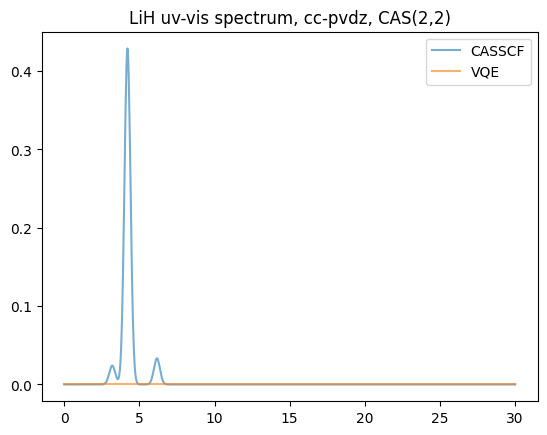

In [19]:
# plot the data
x = np.linspace(0, 30, 1000)
y = np.zeros_like(x)


df_spectrum = df[df["scale"] == 1.0].reset_index()
df_spectrum_vqe = vqe_df[vqe_df["scale"] == 1.0].reset_index()
for i in range(len(df_spectrum)):
    y += gaussian(
        x,
        df_spectrum.loc[i, "Energy_eV"],
        df_spectrum.loc[i, "Oscillator_F_Total"]
    )
plt.plot(x, y, label = "CASSCF", alpha=0.6)

y = np.zeros_like(x)
for i in range(len(df_spectrum_vqe)):
    y += gaussian(
        x,
        df_spectrum_vqe.loc[i, "Energy_eV"],
        df_spectrum_vqe.loc[i, "Oscillator_F_Total"]
    )
plt.plot(x, y, label = "VQE", alpha=0.6)

plt.title("LiH uv-vis spectrum, cc-pvdz, CAS(2,2)")

plt.legend()

In [73]:
df_spectrum_vqe

,level_0,index,State,Energy_eV,scale,Oscillator_F_Total
0,0,0,1,0.000000,1.0,0.000000
1,1,1,2,4.112775,1.0,0.058624
2,2,2,3,18.546977,1.0,0.000529


In [74]:
df_spectrum

,index,State,Energy_au,Energy_eV,Oscillator_F_X,Oscillator_F_Y,Oscillator_F_Z,Oscillator_F_Total,scale
0,0,1,0.117266,3.190969,5.234844e-31,3.229436e-30,2.409833e-02,0.024098,1.0
1,1,2,0.154503,4.204251,1.407421e-01,7.374023e-02,1.700936e-30,0.214482,1.0
2,2,3,0.154503,4.204251,7.374049e-02,1.407429e-01,1.177415e-30,0.214483,1.0
3,3,4,0.226526,6.164084,8.934914e-31,3.446830e-30,3.339067e-02,0.033391,1.0
4,4,5,0.259642,7.065226,6.174513e-30,9.143434e-32,4.762673e-03,0.004763,1.0
5,5,6,0.262577,7.145096,9.931272e-03,5.203315e-03,1.773102e-27,0.015135,1.0
